<a href="https://colab.research.google.com/github/kauefs/ML/blob/%40/notebooks/CreditRisk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<font color=F0F0F0 size=8px font-family=Georgia>
<strong><ins>ƊⱭȾɅViƧi&#x1F9FF;Ƞ</ins>&trade;</strong></font>

[![AIaaS      ](https://img.shields.io/badge/Artificial_Intelligence_as_a_Service-FFFFFF?style=plastic&label=ƊⱭȾɅViƧi&#x1F9FF;Ƞ&trade;&labelColor=0065FF)](https://datavision.one/)

[![GitHub      ](https://img.shields.io/badge/-000000?logo=github&logoColor=FFFFFF)](https://github.com/kauefs/)
[![Medium      ](https://img.shields.io/badge/-000000?logo=medium&logoColor=FFFFFF)](https://medium.com/@kauefs)
[![LinkedIn    ](https://img.shields.io/badge/in-2867B2?logo=linkedin&logoColor=FFFFFF)](https://www.linkedin.com/in/kauefs/)
[![Python      ](https://img.shields.io/badge/3-646464?logo=python&logoColor=FFDE57&labelColor=4584B6)](https://www.python.org/)
[![License     ](https://img.shields.io/badge/MIT-750014?&label=License&labelColor=8B959E)](https://web.mit.edu/Saltzer/www/publications/MITLicense.pdf)

<a href=https://starresearch.institute />
<img alt=SigMoidal src=https://escola.sigmoidal.ai/wp-content/uploads/2024/05/Academia-Sigmoidal-1.png /></a>
</center>

---
#  Credit Risk with XGBoost

Estimating the probability of next month's default with a complete saved PipeLine, from raw data to prediction, ready for new, unseen data.

Objectives
* Reserve **&** preserve the test set
* Encapsulate imputation, encoding, and model in a single PipeLine
* Compare BaseLine, Logistic Regression, and XGBoost
* Use Stratified Cross-Validation **&** adequate metrics for the minority class
* Choose the decision threshold without consulting the test set
* Save **&** load **&** apply the trained model on new data

DataSet: [Default Credit Card Clients](https://doi.org/10.24432/C55S3H) from UCI Machine Learning Repository where each row represents a client and target is default next month.

Feature ReNaming: original columns names renamed for better readability **–** a deterministic transformation that does not learn any statistics from the dataset, thus preventing data leakage.

Features Included: credit limit, age, payment histoy, factures and previous payments. Sex, education and marital status are categorical variables.

Imputation Strategy: although there are no missing values in the raw dataset; imputation steps are included in the PipeLine to handle future incomplete data during inference, ensuring imput statistics are learned strictly from training data.

Metric Strategy: the positive class represents about 22% of clients. Accuracy alone can be misleading for imbalanced DataSets, as a naive model predicting only the majority class would achieve high accuracy. Therefore, PR-AUC is chosen as primary selection metric, with ROC-AUC **&** Balanced Accuracy as complementary metrics.

Problem Definition: for each client, there is an attribute vector $\mathbf{x}^{(i)}\in\mathbb{R}^{d}$ and a binary target $y^{(i)}\in\{0,1\}$. The model producing an estimated probability:

$$
\hat{p}^{(i)} = p\left(y^{(i)}=1\mid\mathbf{x}^{(i)}\right)
$$

Converting this probability into a class label depends on a decision threshold. Decoupling probability estimation from decison-making is critical in risk management.

Note: this is an educational project, predictions alone should not be used to deny credit. Real-world applications require legal compliance, governance, bias audits, continuous monitoring, and human review.

Train **&** Test Split: the Test Set is isolated prior to any transformations, with stratification preserving about the same default ratio across both subsets.

Cross-Validation is performed exclusively on the Training Set. The Test Set is consulted only once, after selecting the final model, tuning hyperparameters, and locking the decision threshold.

TransFormation PipeLine
* Categorical Columns: imputed using mode and encoded with One-Hot Encoding.
*   Numeric   Columns: imputed using median and standardized (while trees do not require scaling, standardizing is necessary for Logistic Regression).

The PipeLine ensures Imputers, Scalers, and Encoders are never fitted on validation or test data. In each cross-validation fold, transformers are fitted strictly on the training fold. No UnderSampling is applied; the observed class balance is preserved to accurately estimate probabilities before adjusting the threshold.

BaseLine **&** Models
* `DummyClassifier`: non-learning BenchMark strategy, contextualizing the other results.
* Logistic Regression: linear relations (BaseLine).
* XGBoost: non-linear model capable of computing complex feature interactions (value of interactions **&** non-linearity).
* Stratified Cross-Validation: identical cross-validation folds are evaluated across all models, reporting the mean and the standard deviation performance metrics.

HyperParaMeter Search: compact **&** controled **&** randomized search demonstrates the workflow without running extensive grid sweeps. The search evaluates the full PipeLine, performing preprocessing inside each fold to keep the evaluation leak-free using PR-AUC.

ThresHold Selection: the model returns probabilities, the default threshold (.5) is rarely optimal for asymmetric risks, it is an operational choice. For demonstration purposes, the threshold that maximizes the F1-Score on out-of-fold training predictions is selected. In production environment, the threshold should align with financial business costs of False Positives $\times$ False Negatives.

Final Evaluation **&** PipeLine Persistence
* Evaluation: the evaluation protocol is fixed with the best PipeLine retrained on the full training set using the threshold determined without touching the test set, and results evaluated via Confusion Matix, which translates the results to individual decisions, and Precision–ReCall Curves, which shows the exchange between finding more defaults **&** generating more incorrect alerts. No metric eliminates the necessity of analysis by subgroup, calibration, costs, and maintenance in the population after implementation.
* Features Importance: XGBoost identifies which attributescontribute most to decision splits (leaves), aiding inspectability for the tree decisions. Note: importance does not imply casuality.
* Persistence: trained PipeLine with chosen ThresHold and expected feature order are packaged into a single ArtiFact. `joblib` **&** `pickle` files can execute code during loading.

Deployment Execution: the deployed application does not require manual preprocessing steps; the saved PipeLine automatically executes the exact transformations learned during training on new raw input data.

Delivery
* Preserved Test Set
* Learned transforms in PipeLine
* BaseLines **&** Stratifyed Cross-Validation
* Small     **&** Reproductible HyperParaMeters Search
* Chosen ThresHold from out-of-fold train predictions
* Final Evaluation with adequate metrics for the minority class
* PipeLine, imputation, and threshold in the same artfact

Next Steps: document decision costs, evaluate calibration **&** performance across sub-populations (fairness/bias), and design a continuous drift monitoring framework **–** all key components of Model Governance beyond Model Training.

In [1]:
# @title Settings
# Libraries
import       numpy                   as   np
import      pandas                   as   pd
import     seaborn                   as   sns
import  matplotlib.pyplot            as   plt
import     xgboost                   as   xgb
import     sklearn, joblib,   torch,      sys
from       pathlib                 import Path
from       sklearn.compose         import ColumnTransformer
from       sklearn.dummy           import DummyClassifier
from       sklearn.impute          import SimpleImputer
from       sklearn.preprocessing   import OneHotEncoder, StandardScaler
from       sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, StratifiedKFold, RandomizedSearchCV
from       sklearn.linear_model    import LogisticRegression
from       sklearn.pipeline        import Pipeline
from       sklearn.metrics         import average_precision_score, balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, ConfusionMatrixDisplay, PrecisionRecallDisplay
from       xgboost                 import XGBClassifier
#   Configs
device=torch.accelerator.current_accelerator( ).type if torch.accelerator.is_available( )else'cpu'
print(f'Python {sys.version} on {device}.')
if     torch.accelerator.is_available  ( ):print(f'GPU {torch.accelerator.get_device_name(0)}')
%matplotlib inline
%config     InlineBackend.figure_format='svg'
%precision        2
seed             =2
np.random.seed   (seed)
torch.manual_seed(seed)
random_state     =seed
session_id       =seed
epochs           =10
pd.options.plotting.matplotlib.register_converters = True
pd.options.display.max_columns         =             None
plt.rcParams[  'figure.autolayout']    =             True
plt.rcParams[  'figure.dpi'       ]    =              300
plt.rcParams[   'font.family'     ]    =                                          'sans-serif'
sns.set_theme(context='notebook', style='whitegrid', palette='colorblind',  font ='sans-serif', font_scale=1.15, color_codes=True, rc={'grid.color':'1','grid.linestyle':':'})
FontT={'family':'sans-serif'    ,'color':'#000000' ,  'size': 13,    'fontweight':'semibold'  }
FontY={'family':'sans-serif'    ,'color':'#FF4500' ,  'size': 10,    'fontweight':'regular'   }
FontX={'family':'sans-serif'    ,'color':'#4CAF50' ,  'size': 10,    'fontweight':'regular'   }

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0] on cpu.


In [2]:
#@title Data Ingestion
# DownLoad Data
URL =    ('https://raw.githubusercontent.com/carlosfab/pos-graduacao-sigmoidal/main/PPG-DS/CS301%20-%20Machine%20Learning%20I/turma-3/data/default_credit_card_clients.csv')
PATH=Path('data/default_credit_card_clients.csv')
if not PATH.exists( ):
    from urllib.request import urlretrieve
    PATH.parent.mkdir(exist_ok=True, parents=True)
    urlretrieve(URL,PATH)
print(f'Data Available @ {PATH}')

Data Available @ data/default_credit_card_clients.csv


In [3]:
# Load Data
DIR  =Path('artifacts')
MODEL=Path('CreditRiskPipeLine.joblib')
if not PATH.exists( ):raise FileNotFoundError(f'File Not Found @ {PATH}')
df=pd.read_csv(PATH)
# Data Info
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       300

In [4]:
#@title Feature ReNaming
base   =[ 'credit_limit','sex','education','marital_status','age']
status =[f'pay_status_{m}' for m in['sep','aug','jul','jun','may','apr']]
bill   =[f'bill_amount_{m}'for m in['sep','aug','jul','jun','may','apr']]
paid   =[f'payment_{m}'    for m in['sep','aug','jul','jun','may','apr']]
feature=base+status+bill+paid
df.columns=feature+['default_next_month']
df#.head( )

,credit_limit,sex,education,marital_status,age,pay_status_sep,pay_status_aug,pay_status_jul,pay_status_jun,pay_status_may,pay_status_apr,bill_amount_sep,bill_amount_aug,bill_amount_jul,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_sep,payment_aug,payment_jul,payment_jun,payment_may,payment_apr,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [5]:
# Summary
summary=pd.DataFrame({ 'type'   :df.dtypes.astype(str),
                       'missing':df.   isna( ).sum(  ),
                       'unique' :df.nunique( )})
summary.sort_values(by='unique', ascending=True)

,type,missing,unique
sex,int64,0,2
default_next_month,int64,0,2
marital_status,int64,0,4
education,int64,0,7
pay_status_apr,int64,0,10
pay_status_may,int64,0,10
pay_status_jul,int64,0,11
pay_status_aug,int64,0,11
pay_status_jun,int64,0,11
pay_status_sep,int64,0,11


In [6]:
# Detailed Target Distribution Summary
target_summary=pd.DataFrame({   'Count'  :df['default_next_month'].value_counts( ).sort_index( ),
                             'Percentage':df['default_next_month'].value_counts(normalize=True).sort_index( )*100}, index=[0,1])
target_summary.index=['0–NonDeFault','1–DeFault']
target_summary.style.format({'Count':'{:,}','Percentage':'{:.2f}%'})

,Count,Percentage
0–NonDeFault,"23,364",77.88%
1–DeFault,"6,636",22.12%


In [7]:
#@title Class Balance
rate=df['default_next_month'].value_counts(normalize=True).sort_index( )
rate.index=['NonDeFault','DeFault']
rate

,proportion
NonDeFault,0.7788
DeFault,0.2212


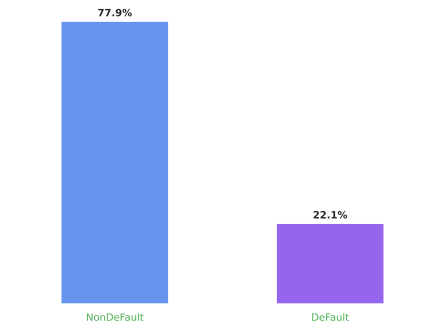

In [8]:
# Plot
fig ,ax=plt.subplots(frameon=True, tight_layout=True)
rate.plot  (kind='bar', color=['#6595EE','#9565EE'], ax=ax)
for p in ax.patches:ax.annotate(f'{p.get_height( ):.1%}',(p.get_x( )+p.get_width( )/2., p.get_height( )),
                ha='center', va='bottom', xytext=(0,3), textcoords='offset points', fontsize=10, fontweight='semibold')
ax  .get_yaxis( ).set_visible(False)
plt .xticks(ticks=[0,1], labels=rate.index, fontdict=FontX, rotation=0)
plt .box   (False)
plt .show  (     )

In [9]:
#@title Train & Test Split
XX=df.drop(columns='default_next_month')
YY=df['default_next_month']
X, x, Y, y = train_test_split(XX, YY, test_size=.2, stratify=YY, random_state=random_state)
print(X.shape, x.shape)

(24000, 23) (6000, 23)


In [10]:
# Proportions
proportions=pd.DataFrame({'train':Y.value_counts(normalize=True),  # Y.mean( ):.2%
                          'teste':y.value_counts(normalize=True)}) # y.mean( ):.2%
proportions.index=['NonDeFault','DeFault']
proportions.style.format('{:.2%}')
proportions

,train,teste
NonDeFault,0.778792,0.778833
DeFault,0.221208,0.221167


In [11]:
#@title TransFormation PipeLine
categorical =['sex','education','marital_status']
numerical   =[col for col in XX.columns if col not in categorical]
numPipe     =Pipeline([('imputer', SimpleImputer(strategy='median')),
                       ('scaler' , StandardScaler( ))])
catPipe     =Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('onehot' , OneHotEncoder(handle_unknown='ignore'))])
preprocessor=ColumnTransformer([('numeric'    , numPipe, numerical),
                                ('categorical', catPipe, categorical)],
                              verbose_feature_names_out=False)
# BaseLine & XGBoost
dummyPipe   =Pipeline([('preprocess', preprocessor),
                       ('model'     , DummyClassifier(strategy='prior'))])
logistPipe  =Pipeline([('preprocess', preprocessor),
                       ('model'     , LogisticRegression(max_iter=2000, random_state=random_state))])
xgbPipe     =Pipeline([('preprocess', preprocessor),
                       ('model'     , XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                                    tree_method='hist', n_estimators=300, max_depth=3,
                                                    learning_rate=.05, random_state=random_state, n_jobs=-1))])
# Cross-Validation
cv     =  StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
scoring={'pr_auc':'average_precision','roc_auc':'roc_auc','balanced_accuracy':'balanced_accuracy'}
models ={'Dummy':dummyPipe,'Logistic':logistPipe,'XGBoost':xgbPipe}
def evaluateCV(name, estimator):
    scores=cross_validate(estimator, X, Y, cv=cv, scoring=scoring, n_jobs=1)
    return {'model':name,
             'PR-AUCstd'      : scores['test_pr_auc' ]          .std ( ),
             'PR-AUCmean'     : scores['test_pr_auc' ]          .mean( ),
            'ROC-AUCmean'     : scores['test_roc_auc']          .mean( ),
            'BalancedAccuracy': scores['test_balanced_accuracy'].mean( )}
resultsCV=pd.DataFrame([evaluateCV(name, model)for name, model in models.items( )])
resultsCV.set_index('model').round(4)

,PR-AUCstd,PR-AUCmean,ROC-AUCmean,BalancedAccuracy
model,,,,
Dummy,0.0001,0.2212,0.5000,0.5000
Logistic,0.0094,0.5056,0.7236,0.6090
XGBoost,0.0139,0.5572,0.7808,0.6572


In [12]:
# HyperParaMeters Search
params={'model__n_estimators'    :[250, 400, 600],
        'model__max_depth'       :[  2,   3,   4],
        'model__learning_rate'   :[.03, .05, .08],
        'model__min_child_weight':[  1,   5,  10],
        'model__subsample'       :[ .7,  .9,  1.],
        'model__colsample_bytree':[ .7,  .9,  1.]}
search=RandomizedSearchCV(xgbPipe, params, n_iter=8, scoring='average_precision', cv=cv,
                          refit=True, random_state=random_state, n_jobs=-1, return_train_score=False)
search.fit(X,Y)
print(f'Best PR-AUC in Validation {search.best_score_:.4f}')

Best PR-AUC in Validation 0.5576


In [13]:
bestParams={key.replace('model__',''):value for key, value in search.best_params_.items( )}
bestParams

{'subsample': 0.90,
 'n_estimators': 250,
 'min_child_weight': 5,
 'max_depth': 3,
 'learning_rate': 0.03,
 'colsample_bytree': 0.70}

In [14]:
#   ThresHold
# Out-of-Fold
oofProba=cross_val_predict(search.best_estimator_, X, Y, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
precision,recall,thresholds=precision_recall_curve(Y, oofProba)
f1Values =2*precision[:-1]*recall[:-1]/(precision[:-1]+recall[:-1]+1e-9)
bestThresHold=thresholds[np.argmax(f1Values)]
print(f'Chosen Train ThresHold {bestThresHold:.4f}')

Chosen Train ThresHold 0.2572


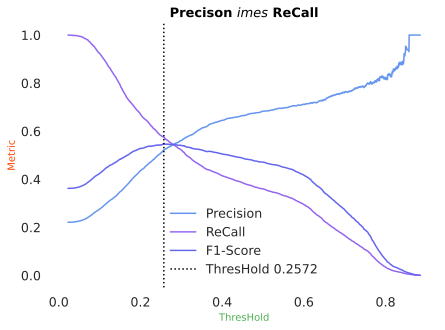

In [15]:
# Plot
plt.plot(thresholds, precision[:-1], label='Precision', color='#6595EE')
plt.plot(thresholds,    recall[:-1], label='ReCall'   , color='#9565EE')
plt.plot(thresholds,  f1Values     , label='F1-Score' , color='#6565EE')
plt.axvline(bestThresHold, color='#000000', linestyle=':', label=f'ThresHold {bestThresHold:.4f}')
plt.title ('Precison $\times$ ReCall'     , fontdict=FontT)
plt.xlabel('ThresHold'                    , fontdict=FontX)
plt.ylabel('Metric'                       , fontdict=FontY)
plt.legend(frameon=False)
plt.box           (False)
plt.show( )

In [16]:
#@title Final Evaluation
finalPipe   = search.best_estimator_
proba       = finalPipe.predict_proba(x)[:,1]
pred        =(proba>=bestThresHold).astype(int)
finalMetrics= pd.Series({# Independent Metrics (Model Ranking Quality)
                         'PR-AUC'         :average_precision_score(y, proba),
                         'ROC-AUC'         :roc_auc_score          (y, proba),
                         #   Dependent Metrics (Operational Decisions)
                         'Precision'       :precision_score        (y, pred ),
                         'ReCall'          :recall_score           (y, pred ),
                         'F1'              :f1_score               (y, pred ),
                         'BalancedAccuracy':balanced_accuracy_score(y, pred )})
finalMetrics.round(4)

,0
PR-AUC,0.5552
ROC-AUC,0.7855
Precision,0.5181
ReCall,0.5833
F1,0.5487
BalancedAccuracy,0.7146


In [17]:
# DataFrame
metricsDF=pd.DataFrame({'Metric Type':['Ranking','Ranking','Decision (ThresHold)','Decision (ThresHold)','Decision (ThresHold)','Decision (ThresHold)'],
                              'Score':[average_precision_score(y, proba),
                                                 roc_auc_score(y, proba),
                                               precision_score(y, pred ),
                                                  recall_score(y, pred ),
                                                      f1_score(y, pred ),
                                       balanced_accuracy_score(y, pred )]},
                       index=['PR-AUC','ROC-AUC','Precision','ReCall','F1','Balanced Accuracy'])
metricsDF.round(4)

,Metric Type,Score
PR-AUC,Ranking,0.5552
ROC-AUC,Ranking,0.7855
Precision,Decision (ThresHold),0.5181
ReCall,Decision (ThresHold),0.5833
F1,Decision (ThresHold),0.5487
Balanced Accuracy,Decision (ThresHold),0.7146


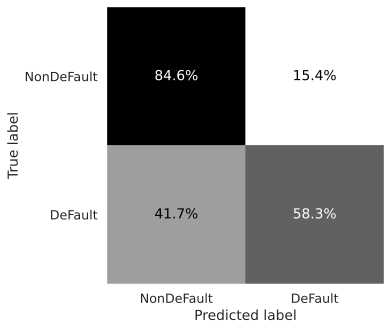

In [18]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y, pred, display_labels=['NonDeFault','DeFault'], cmap='binary', normalize='true', values_format='.1%', colorbar=False)
plt.grid(False)
plt.box (False)
plt.show(     )

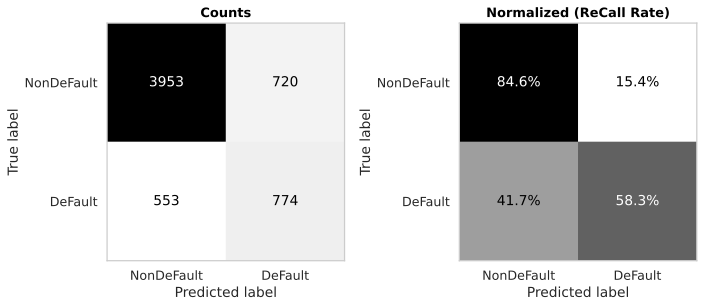

In [19]:
fig,axes=plt.subplots(1, 2, figsize=(10, 5), frameon=True, tight_layout=True)
# Absolute Counts
ConfusionMatrixDisplay.from_predictions(y, pred, display_labels=['NonDeFault','DeFault'], cmap='binary', colorbar=False, ax=axes[0])
axes[0].set_title('Counts', fontdict=FontT)
axes[0].grid(False)
# Normalized Proportions
ConfusionMatrixDisplay.from_predictions(y, pred, display_labels=['NonDeFault','DeFault'], cmap='binary', normalize='true', values_format='.1%', colorbar=False, ax=axes[1])
axes[1].set_title('Normalized (ReCall Rate)', fontdict=FontT)
axes[1].grid(False)
plt.show( )

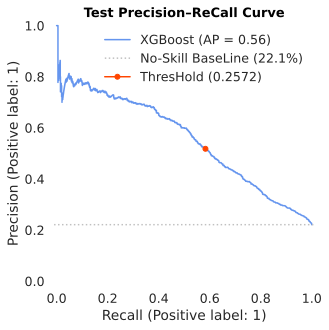

In [20]:
# OverLay Operating Point
BaseLine     =        y.mean (       )
testPrecision=precision_score(y, pred)
testReCall   =   recall_score(y, pred)
PrecisionRecallDisplay.from_predictions(y, proba, color='#6595EE', name='XGBoost')
plt.axhline(BaseLine, color='#C0C0C0', linestyle=':', label=f'No-Skill BaseLine ({BaseLine:.1%})')
plt.plot   (testReCall, testPrecision, marker='o', markersize=5, color='#FF4500', label=f'ThresHold ({bestThresHold:.4f})')
plt.title  ('Test Precision–ReCall Curve' , fontdict=FontT)
plt.legend (frameon=False)
plt.box    (        False)
plt.show   (             )

In [21]:
# Feature Importances
fitPreProcessor =finalPipe.named_steps['preprocess']
fitModel        =finalPipe.named_steps[    'model' ]
transformedNames=fitPreProcessor.get_feature_names_out( )
importances     =pd.Series(fitModel.feature_importances_, index=transformedNames).sort_values( ).tail(12)
importances

,0
bill_amount_sep,0.016717
payment_aug,0.020986
payment_jun,0.022627
credit_limit,0.027706
payment_sep,0.028524
payment_jul,0.030769
pay_status_apr,0.039116
pay_status_jun,0.044601
pay_status_may,0.057501
pay_status_aug,0.068632


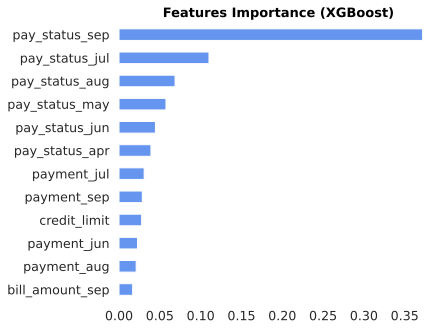

In [22]:
# Plot
importances.plot(kind='barh', color='#6595EE')
plt.title('Features Importance (XGBoost)', fontdict=FontT)
plt.box  ( False)
plt.show (      )

In [23]:
# PipeLine Persistence
DIR.mkdir(exist_ok=True, parents=True)
artifact={'pipeline':finalPipe,'threshold':float(bestThresHold),'feature_names':list(X.columns),
          'target_name':'default_next_month','versions':{'scikit-learn':sklearn.__version__,'xgboost':xgb.__version__,'pandas':pd.__version__}}
joblib.dump(artifact, MODEL)
print(MODEL, f'{MODEL.stat( ).st_size/1024:.0f}KB')

CreditRiskPipeLine.joblib 296KB


In [24]:
# Loading ArtiFact
loadedArtiFact =joblib.load    (MODEL)
loadedPipeLine =loadedArtiFact['pipeline' ]
loadedThresHold=loadedArtiFact['threshold']
print(type(loadedPipeLine).__name__)
print(f'Loaded ThresHold {loadedThresHold:.4f}')
print(loadedArtiFact['versions'])

Pipeline
Loaded ThresHold 0.2572
{'scikit-learn': '1.6.1', 'xgboost': '3.3.0', 'pandas': '2.2.2'}


In [25]:
# UnSeen Data
Client     =   x.iloc[[0]].copy( )
transformer=loadedPipeLine.named_steps['preprocess']
transformedClient=transformer.transform(Client)
print(f'     Raw    {Client.shape}\nTransFormed {transformedClient.shape}')

     Raw    (1, 23)
TransFormed (1, 33)


In [26]:
#@title Live Prediction
def HighLight(val):
    if   val=='Approve'      :return'background-color:#4CAF50;color:#F0F0F0;font-weight:semibold'
    elif val=='Deny/HighRisk':return'background-color:#FF4500;color:#F0F0F0;font-weight:semibold'
    return''
def RiskPredict(Data, ArtiFact):
    columns=ArtiFact['feature_names']
    missing=sorted(set(columns)-set(Data.columns))
    if missing:raise ValueError(f'Missing Columns: {missing}')
    prepared     =Data.loc[:, columns].copy( )
    probabilities=ArtiFact['pipeline'].predict_proba(prepared)[:,1]
    predictions  =(probabilities >= ArtiFact['threshold']).astype(int)
    labels       =pd.Series(predictions, index=Data.index).map({0:'NonDeFault',1:'DeFault'})
    actions      =pd.Series(predictions, index=Data.index).map({0:'Approve'   ,1:'Deny/HighRisk'})
    return pd.DataFrame({'prob_default':probabilities,'prediction':predictions,'label':labels,'action':actions}, index=Data.index)
prediction=RiskPredict(Client, loadedArtiFact)
prediction.style.format({'prob_default':'{:.1%}'})\
                .map(HighLight, subset=['action'])

,prob_default,prediction,label,action
28531,79.5%,1,DeFault,Deny/HighRisk
